# 04 Waddington Simulation Summary

Stripped-down Waddington landscape simulation code plus one figure cell for the 24-starting-point trajectory summary. The potential surface is used for simulation only and is not displayed in the final figure.

In [1]:

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path('/Users/nick/Projects/repositories/morphseq/results/nlammers/20260612')
CACHE_DIR = Path('/Users/nick/Projects/data/morphseq/results/20260612')
FIG_DIR = Path('/Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Aim 2')
FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': 12,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'axes.grid': False,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

START_X = -1.55
BIFURCATION_FEATURE1 = START_X - 0.20
BIFURCATION_TRANSITION_WIDTH = 0.30
BRANCH_STRENGTH = 4.0
TRUNK_BROADENING_SCALE = 0.18
TERMINAL_BASIN_Y = 1.55
TERMINAL_WELL_DEPTH = 5.0


N_START_POINTS = 24
N_TRAJECTORIES_PER_START = 10
DT = 0.025
FORWARD_TIME_WINDOW = 3.0
INCOMING_TIME_WINDOW = 1.5
N_STEPS_FORWARD = int(round(FORWARD_TIME_WINDOW / DT)) + 1
N_STEPS_INCOMING = int(round(INCOMING_TIME_WINDOW / DT)) + 1
N_STEPS = N_STEPS_FORWARD
DIFFUSION = 0.0035
MOBILITY = 1.0
TRAJECTORY_SMOOTHING_SIGMA = 8.0
INITIALIZATION_SEED = 20260612
SIMULATION_SEED = 81012
BOTTOM_BASIN_COLOR = '#5294D0'
BOTTOM_BASIN_FILL = '#B9D6EF'
TOP_BASIN_COLOR = '#F08662'
TOP_BASIN_FILL = '#F8CDBF'
INCOMING_TRUNK_COLOR = '#9A9A9A'
INCOMING_TRUNK_FILL = '#E6E6E6'
BASIN_THRESHOLD = 0.0

print(FIG_DIR)


/Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Aim 2


In [2]:

INCOMING_TRUNK_START_Y = -2.0
INCOMING_TRUNK_START_SPREAD_SCALE = 0.12
INCOMING_TRUNK_CURVE_POWER = 1.65
INCOMING_TRUNK_NOISE_SD = 0.018



def simulate_potential_surface(
    feature1_lim=(-3.0, 3.0),
    feature2_lim=(-2.4, 2.4),
    n_grid=360,
    split_feature1=BIFURCATION_FEATURE1,
    transition_width=BIFURCATION_TRANSITION_WIDTH,
    branch_strength=BRANCH_STRENGTH,
    trunk_broadening_scale=TRUNK_BROADENING_SCALE,
    terminal_basin_y=TERMINAL_BASIN_Y,
    terminal_well_depth=TERMINAL_WELL_DEPTH,
    directionality_slope=0.8,
    feature1_curvature=0.035,
    branch_bias=0.0,
):
    """Return a 2D Waddington-like potential with one valley splitting into two.

    `trunk_broadening_scale` weakens only the pre-bifurcation restoring force,
    broadening the initial valley while preserving strong post-bifurcation wells.
    """
    feature1 = np.linspace(*feature1_lim, n_grid)
    feature2 = np.linspace(*feature2_lim, n_grid)
    F1, F2 = np.meshgrid(feature1, feature2)

    sigmoid = 1 / (1 + np.exp(-(F1 - split_feature1) / transition_width))
    raw_bifurcation = branch_strength * (2 * sigmoid - 1)
    post_bifurcation = terminal_basin_y**2 * np.clip(2 * sigmoid - 1, 0, None)
    bifurcation = np.where(
        raw_bifurcation < 0,
        raw_bifurcation * trunk_broadening_scale,
        post_bifurcation,
    )

    branch_potential = terminal_well_depth * (0.25 * F2**4 - 0.5 * bifurcation * F2**2)
    directionality_potential = -directionality_slope * F1 + feature1_curvature * F1**2
    asymmetric_nudge = branch_bias * sigmoid * F2

    U = branch_potential + directionality_potential + asymmetric_nudge
    U -= U.min()

    return {
        'feature1': feature1,
        'feature2': feature2,
        'F1': F1,
        'F2': F2,
        'U': U,
        'split_feature1': split_feature1,
        'bifurcation': bifurcation,
    }


surface = simulate_potential_surface(split_feature1=BIFURCATION_FEATURE1)
surface['U'].shape, surface['U'].min(), surface['U'].max()

((360, 360), 0.0, 63.53803404399969)

In [3]:

def bilinear_sample(values, x_grid, y_grid, points):
    """Sample a regular 2D grid at continuous x/y points."""
    x = np.clip(points[:, 0], x_grid[0], x_grid[-1])
    y = np.clip(points[:, 1], y_grid[0], y_grid[-1])

    ix = np.searchsorted(x_grid, x, side='right') - 1
    iy = np.searchsorted(y_grid, y, side='right') - 1
    ix = np.clip(ix, 0, len(x_grid) - 2)
    iy = np.clip(iy, 0, len(y_grid) - 2)

    x0 = x_grid[ix]
    x1 = x_grid[ix + 1]
    y0 = y_grid[iy]
    y1 = y_grid[iy + 1]
    wx = (x - x0) / (x1 - x0)
    wy = (y - y0) / (y1 - y0)

    v00 = values[iy, ix]
    v10 = values[iy, ix + 1]
    v01 = values[iy + 1, ix]
    v11 = values[iy + 1, ix + 1]

    return (
        (1 - wx) * (1 - wy) * v00
        + wx * (1 - wy) * v10
        + (1 - wx) * wy * v01
        + wx * wy * v11
    )


def smooth_trajectories(trajectories, smoothing_sigma):
    """Apply light Gaussian smoothing along each trajectory's time axis."""
    if smoothing_sigma is None or smoothing_sigma <= 0:
        return trajectories

    radius = max(1, int(np.ceil(3 * smoothing_sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / smoothing_sigma) ** 2)
    kernel /= kernel.sum()

    smoothed = np.empty_like(trajectories)
    for traj_idx in range(trajectories.shape[0]):
        for dim_idx in range(trajectories.shape[2]):
            padded = np.pad(trajectories[traj_idx, :, dim_idx], radius, mode='edge')
            smoothed[traj_idx, :, dim_idx] = np.convolve(padded, kernel, mode='valid')
    return smoothed


def simulate_langevin_trajectories(
    surface,
    start,
    n_trajectories=N_TRAJECTORIES_PER_START,
    n_steps=N_STEPS,
    dt=DT,
    diffusion=DIFFUSION,
    mobility=MOBILITY,
    smoothing_sigma=TRAJECTORY_SMOOTHING_SIGMA,
    seed=8,
    reverse_time=False,
):
    """Simulate overdamped Langevin dynamics on a potential surface.

    Forward update is x[t + 1] = x[t] - mobility * grad(U) * dt + sqrt(2Ddt) * noise.
    With reverse_time=True, the deterministic drift is reversed; after plotting the
    simulated path backward this gives a visual trajectory leading into the start.
    """
    rng = np.random.default_rng(seed)
    x_grid = surface['feature1']
    y_grid = surface['feature2']
    U = surface['U']

    grad_y, grad_x = np.gradient(U, y_grid, x_grid)
    trajectories = np.empty((n_trajectories, n_steps, 2), dtype=float)
    trajectories[:, 0, :] = np.asarray(start, dtype=float)

    noise_scale = np.sqrt(2 * diffusion * dt)
    lower = np.array([x_grid[0], y_grid[0]])
    upper = np.array([x_grid[-1], y_grid[-1]])
    drift_sign = 1.0 if reverse_time else -1.0

    for step in range(1, n_steps):
        current = trajectories[:, step - 1, :]
        local_grad = np.column_stack([
            bilinear_sample(grad_x, x_grid, y_grid, current),
            bilinear_sample(grad_y, x_grid, y_grid, current),
        ])
        drift = drift_sign * mobility * local_grad * dt
        noise = noise_scale * rng.normal(size=current.shape)
        trajectories[:, step, :] = np.clip(current + drift + noise, lower, upper)

    return {
        'raw': trajectories,
        'smoothed': smooth_trajectories(trajectories, smoothing_sigma),
        'params': {
            'start': start,
            'n_trajectories': n_trajectories,
            'n_steps': n_steps,
            'dt': dt,
            'diffusion': diffusion,
            'mobility': mobility,
            'smoothing_sigma': smoothing_sigma,
            'seed': seed,
            'reverse_time': reverse_time,
        },
    }


## Time-parameterized forward and backward trajectories from 24 random starts along x = -1.55

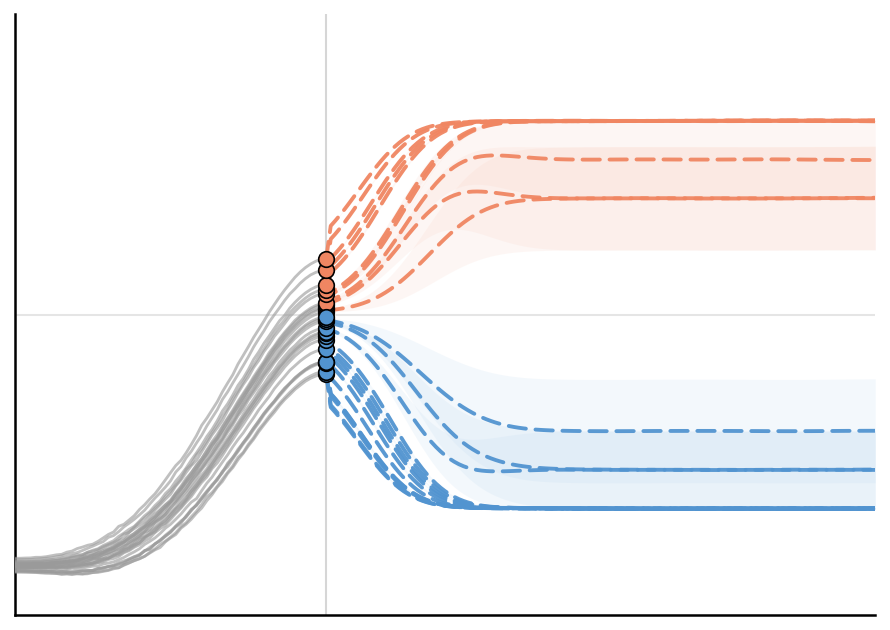

,start_idx,start_x,start_y,incoming_start_y,marker_time,basin,bottom_fraction,top_fraction,mean_endpoint_x,mean_endpoint_y
0,0,-1.55,-0.473339,-2.056801,0.2,bottom,1.0,0.0,1.744763,-1.551984
1,1,-1.55,-0.454801,-2.054576,0.2,bottom,1.0,0.0,1.766043,-1.550094
2,2,-1.55,-0.386624,-2.046395,0.2,bottom,1.0,0.0,1.726682,-1.546863
3,3,-1.55,-0.377802,-2.045336,0.2,bottom,1.0,0.0,1.706599,-1.547496
4,4,-1.55,-0.377505,-2.045301,0.2,bottom,1.0,0.0,1.770521,-1.549595
5,5,-1.55,-0.276280,-2.033154,0.2,bottom,1.0,0.0,1.676644,-1.546961
6,6,-1.55,-0.199787,-2.023974,0.2,bottom,1.0,0.0,1.757715,-1.549475
7,7,-1.55,-0.169427,-2.020331,0.2,bottom,1.0,0.0,1.703684,-1.546168
8,8,-1.55,-0.149561,-2.017947,0.2,bottom,1.0,0.0,1.670319,-1.547747
9,9,-1.55,-0.139101,-2.016692,0.2,bottom,1.0,0.0,1.677267,-1.549887


In [4]:

def basin_from_endpoint(mean_endpoint_y):
    return 'bottom' if mean_endpoint_y < 0 else 'top'


def style_for_basin(basin):
    if basin == 'bottom':
        return BOTTOM_BASIN_COLOR, BOTTOM_BASIN_FILL, 5
    return TOP_BASIN_COLOR, TOP_BASIN_FILL, 4


def smoothstep(x):
    x = np.clip(np.asarray(x, dtype=float), 0, 1)
    return x * x * (3 - 2 * x)


def simulate_incoming_trunk(start_y, seed):
    """Create a tight curved incoming trunk that broadens into the start point."""
    rng = np.random.default_rng(seed)
    progress = np.linspace(0, 1, N_STEPS_INCOMING)
    curve = progress ** INCOMING_TRUNK_CURVE_POWER
    center = INCOMING_TRUNK_START_Y * (1 - smoothstep(curve))
    spread_weight = INCOMING_TRUNK_START_SPREAD_SCALE + (1 - INCOMING_TRUNK_START_SPREAD_SCALE) * smoothstep(progress)
    mean_feature = center + float(start_y) * spread_weight

    noise_profile = INCOMING_TRUNK_NOISE_SD * np.sin(np.pi * progress)
    noise = rng.normal(size=(N_TRAJECTORIES_PER_START, N_STEPS_INCOMING)) * noise_profile
    feature = mean_feature[None, :] + noise
    feature[:, 0] = INCOMING_TRUNK_START_Y + INCOMING_TRUNK_START_SPREAD_SCALE * float(start_y)
    feature[:, -1] = float(start_y)

    trajectories = np.zeros((N_TRAJECTORIES_PER_START, N_STEPS_INCOMING, 2), dtype=float)
    trajectories[:, :, 0] = START_X
    trajectories[:, :, 1] = feature
    return trajectories


def summarize_starting_point(start_idx, start_y):
    start = (START_X, float(start_y))
    forward_ensemble = simulate_langevin_trajectories(
        surface,
        start=start,
        n_trajectories=N_TRAJECTORIES_PER_START,
        n_steps=N_STEPS_FORWARD,
        dt=DT,
        diffusion=DIFFUSION,
        mobility=MOBILITY,
        smoothing_sigma=TRAJECTORY_SMOOTHING_SIGMA,
        seed=SIMULATION_SEED + start_idx,
        reverse_time=False,
    )
    forward_trajectories = forward_ensemble['smoothed']
    forward_trajectories[:, 0, :] = np.asarray(start, dtype=float)
    backward_trajectories = simulate_incoming_trunk(
        start_y=start_y,
        seed=SIMULATION_SEED + 10_000 + start_idx,
    )

    forward_mean = forward_trajectories.mean(axis=0)
    backward_mean = backward_trajectories.mean(axis=0)
    forward_sd = forward_trajectories.std(axis=0, ddof=1)
    backward_sd = backward_trajectories.std(axis=0, ddof=1)
    endpoint_y = forward_trajectories[:, -1, 1]
    mean_endpoint_y = float(forward_mean[-1, 1])
    basin = basin_from_endpoint(mean_endpoint_y)

    return {
        'start_idx': start_idx,
        'start': np.array(start),
        'forward_trajectories': forward_trajectories,
        'backward_trajectories': backward_trajectories,
        'forward_mean': forward_mean,
        'backward_mean': backward_mean,
        'forward_sd': forward_sd,
        'backward_sd': backward_sd,
        'basin': basin,
        'bottom_fraction': float(np.mean(endpoint_y < 0)),
        'top_fraction': float(np.mean(endpoint_y >= 0)),
        'mean_endpoint_y': mean_endpoint_y,
    }


MARKER_TIME = 0.20
init_rng = np.random.default_rng(INITIALIZATION_SEED)
start_y_values = np.sort(init_rng.uniform(-0.5, 0.5, size=N_START_POINTS))
trajectory_summaries = [
    summarize_starting_point(start_idx, start_y)
    for start_idx, start_y in enumerate(start_y_values)
]
forward_time = np.linspace(MARKER_TIME, MARKER_TIME + FORWARD_TIME_WINDOW, N_STEPS_FORWARD)
incoming_time = np.linspace(-INCOMING_TIME_WINDOW, MARKER_TIME, N_STEPS_INCOMING)

summary_rows = []
for summary in trajectory_summaries:
    summary_rows.append({
        'start_idx': summary['start_idx'],
        'start_x': summary['start'][0],
        'start_y': summary['start'][1],
        'incoming_start_y': summary['backward_mean'][0, 1],
        'marker_time': MARKER_TIME,
        'basin': summary['basin'],
        'bottom_fraction': summary['bottom_fraction'],
        'top_fraction': summary['top_fraction'],
        'mean_endpoint_x': summary['forward_mean'][-1, 0],
        'mean_endpoint_y': summary['mean_endpoint_y'],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(FIG_DIR / 'waddington_24_starting_point_summary_time_parameterized.csv', index=False)

fig, ax = plt.subplots(figsize=(7.4, 5.2))

# Draw top first, then bottom so the blue basin remains visible where paths overlap.
for basin in ['top', 'bottom']:
    for summary in [s for s in trajectory_summaries if s['basin'] == basin]:
        line_color, fill_color, zorder = style_for_basin(basin)

        incoming_feature = summary['backward_mean'][:, 1]
        incoming_se = summary['backward_sd'][:, 1] / np.sqrt(N_TRAJECTORIES_PER_START)
        forward_feature = summary['forward_mean'][:, 1]
        forward_se = summary['forward_sd'][:, 1] / np.sqrt(N_TRAJECTORIES_PER_START)

        ax.fill_between(
            incoming_time,
            incoming_feature - incoming_se,
            incoming_feature + incoming_se,
            color=INCOMING_TRUNK_FILL,
            alpha=0.10,
            linewidth=0,
            zorder=zorder - 1,
        )
        ax.fill_between(
            forward_time,
            forward_feature - forward_se,
            forward_feature + forward_se,
            color=fill_color,
            alpha=0.16,
            linewidth=0,
            zorder=zorder - 1,
        )
        ax.plot(
            incoming_time,
            incoming_feature,
            color=INCOMING_TRUNK_COLOR,
            lw=1.35,
            alpha=0.62,
            linestyle='-',
            solid_capstyle='round',
            zorder=zorder,
        )
        ax.plot(
            forward_time,
            forward_feature,
            color=line_color,
            lw=1.85,
            alpha=0.95,
            linestyle=(0, (4.5, 2.5)),
            dash_capstyle='round',
            zorder=zorder,
        )
        ax.scatter(
            [MARKER_TIME],
            [summary['start'][1]],
            s=56,
            color=line_color,
            edgecolor='black',
            linewidth=0.8,
            zorder=8,
        )

ax.axvline(MARKER_TIME, color='black', lw=1.0, alpha=0.16, zorder=0)
ax.axhline(0, color='black', lw=1.0, alpha=0.10, zorder=0)
ax.set_xlim(-INCOMING_TIME_WINDOW, MARKER_TIME + FORWARD_TIME_WINDOW)
ax.set_ylim(surface['feature2'][0], surface['feature2'][-1])
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False, length=0)

for suffix in ['png', 'pdf']:
    fig.savefig(FIG_DIR / f'waddington_24_starting_points_time_parameterized_summary.{suffix}', dpi=300)

plt.show()
summary_df


/Users/nick/miniforge3/envs/morphseq-env/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/nick/miniforge3/envs/morphseq-env/lib/python3.10/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


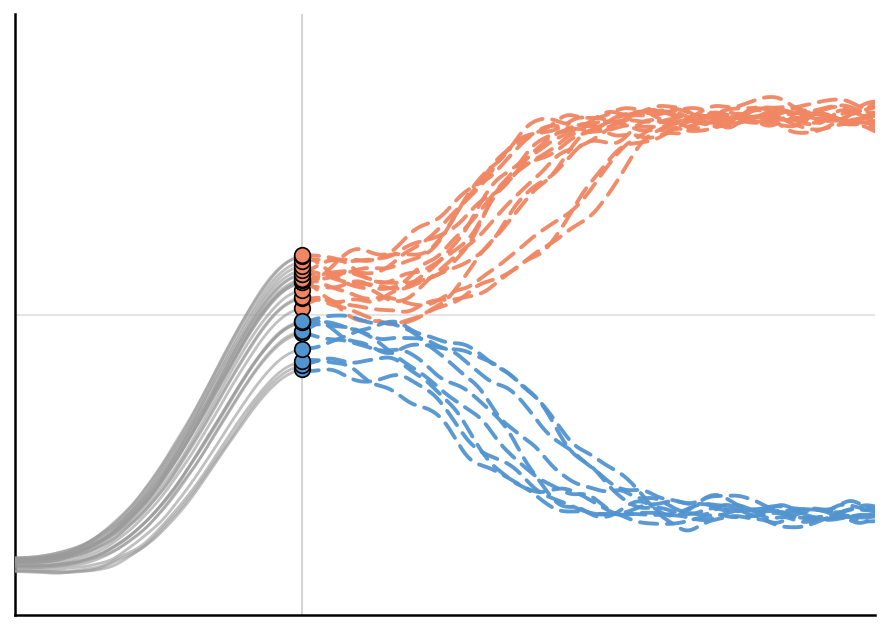

,start_idx,marker_t,start_y,basin,branchpoint_t,mean_endpoint_y,bottom_fraction,top_fraction
0,0,0.0,-0.436183,bottom,0.3,-1.532965,1.0,0.0
1,1,0.0,-0.405823,bottom,0.3,-1.604022,1.0,0.0
2,2,0.0,-0.371886,bottom,0.3,-1.649974,1.0,0.0
3,3,0.0,-0.272761,bottom,0.3,-1.564177,1.0,0.0
4,4,0.0,-0.145474,bottom,0.3,-1.558279,1.0,0.0
5,5,0.0,-0.129202,bottom,0.3,-1.612008,1.0,0.0
6,6,0.0,-0.061122,bottom,0.3,-1.631629,1.0,0.0
7,7,0.0,-0.056586,bottom,0.3,-1.589511,1.0,0.0
8,8,0.0,-0.049614,bottom,0.3,-1.559233,1.0,0.0
9,9,0.0,0.054585,top,0.3,1.614292,0.0,1.0


In [11]:
# SELF_CONTAINED_WADDINGTON_TIME_POTENTIAL_CELL
# Run this cell by itself after a kernel restart if needed.
# The editable parameters are grouped here at the top.

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --------------------
# Edit these parameters
# --------------------
FIG_DIR = Path('/Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Aim 2')
OUTPUT_STEM = 'waddington_self_contained_time_potential_summary'

N_START_POINTS = 24
N_TRAJECTORIES_PER_START = 1
START_Y_LOW = -0.5
START_Y_HIGH = 0.5

MARKER_T = 0.0
INCOMING_START_T = -1.5
FORWARD_END_T = 3.0
DT = 0.015

# Requested geometry/noise knobs.
TRAJECTORY_NOISE = 0.2
SHOW_UNCERTAINTY = False
BRANCHPOINT_T = 0.30
Y_SEPARATION_OF_WELLS = 3.20
WELL_DEPTH = 3

# Useful secondary knobs, still changing the potential/trajectory geometry.
BRANCH_TRANSITION_WIDTH = 0.42
PREBRANCH_DIVERGENCE = 0.025
TRAJECTORY_SMOOTHING_SIGMA = 3.0
INCOMING_START_Y = -2.0
INCOMING_START_SPREAD_SCALE = 0.12
INCOMING_CURVE_POWER = 1.65
INCOMING_NOISE = 0.018
INITIALIZATION_SEED = 42
SIMULATION_SEED = 81012

BOTTOM_BASIN_COLOR = '#5294D0'
BOTTOM_BASIN_FILL = '#B9D6EF'
TOP_BASIN_COLOR = '#F08662'
TOP_BASIN_FILL = '#F8CDBF'
INCOMING_TRUNK_COLOR = '#9A9A9A'
INCOMING_TRUNK_FILL = '#E6E6E6'

FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': 12,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'axes.grid': False,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})


def smoothstep(x):
    x = np.clip(np.asarray(x, dtype=float), 0, 1)
    return x * x * (3 - 2 * x)


def smooth_trajectories(trajectories, smoothing_sigma):
    if smoothing_sigma is None or smoothing_sigma <= 0:
        return trajectories

    radius = max(1, int(np.ceil(3 * smoothing_sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / smoothing_sigma) ** 2)
    kernel /= kernel.sum()

    smoothed = np.empty_like(trajectories)
    for traj_idx in range(trajectories.shape[0]):
        padded = np.pad(trajectories[traj_idx], radius, mode='edge')
        smoothed[traj_idx] = np.convolve(padded, kernel, mode='valid')
    return smoothed


def branch_activation(t):
    return smoothstep((np.asarray(t) - BRANCHPOINT_T) / BRANCH_TRANSITION_WIDTH)


def double_well_force(y, t):
    """Force from a rounded, flat-bottomed time-dependent double well.

    This is the negative gradient of a log-rounded double-well potential, not
    endpoint post-processing. Larger well_flatness makes the bottoms visibly
    broader while preserving the two-well geometry.
    """
    activation = branch_activation(t)
    half_sep = 0.5 * Y_SEPARATION_OF_WELLS
    delta = half_sep**2 - y**2
    well_flatness = 2.0 * half_sep
    postbranch_force = (
        WELL_DEPTH
        * activation
        * 4
        * y
        * delta
        * well_flatness**2
        / (well_flatness**4 + delta**2)
    )
    prebranch_force = PREBRANCH_DIVERGENCE * (1 - activation) * y
    return prebranch_force + postbranch_force


def simulate_forward_trajectories(start_y, seed):
    rng = np.random.default_rng(seed)
    time = np.arange(MARKER_T, FORWARD_END_T + DT * 0.5, DT)
    trajectories = np.empty((N_TRAJECTORIES_PER_START, len(time)), dtype=float)
    trajectories[:, 0] = float(start_y)
    noise_scale = TRAJECTORY_NOISE * np.sqrt(DT)

    for step in range(1, len(time)):
        y = trajectories[:, step - 1]
        t_prev = time[step - 1]
        drift = double_well_force(y, t_prev) * DT
        noise = noise_scale * rng.normal(size=N_TRAJECTORIES_PER_START)
        trajectories[:, step] = np.clip(y + drift + noise, -2.35, 2.35)

    trajectories = smooth_trajectories(trajectories, TRAJECTORY_SMOOTHING_SIGMA)
    trajectories[:, 0] = float(start_y)
    return time, trajectories


def simulate_incoming_trunk(start_y, seed):
    rng = np.random.default_rng(seed)
    time = np.arange(INCOMING_START_T, MARKER_T + DT * 0.5, DT)
    progress = np.linspace(0, 1, len(time))
    curve = progress ** INCOMING_CURVE_POWER
    center = INCOMING_START_Y * (1 - smoothstep(curve))
    spread_weight = INCOMING_START_SPREAD_SCALE + (1 - INCOMING_START_SPREAD_SCALE) * smoothstep(progress)
    mean_feature = center + float(start_y) * spread_weight

    noise_profile = INCOMING_NOISE * np.sin(np.pi * progress)
    noise = rng.normal(size=(N_TRAJECTORIES_PER_START, len(time))) * noise_profile
    trajectories = mean_feature[None, :] + noise
    trajectories[:, 0] = INCOMING_START_Y + INCOMING_START_SPREAD_SCALE * float(start_y)
    trajectories[:, -1] = float(start_y)
    trajectories = smooth_trajectories(trajectories, TRAJECTORY_SMOOTHING_SIGMA)
    trajectories[:, -1] = float(start_y)
    return time, trajectories


def basin_from_endpoint(mean_endpoint_y):
    return 'bottom' if mean_endpoint_y < 0 else 'top'


def style_for_basin(basin):
    if basin == 'bottom':
        return BOTTOM_BASIN_COLOR, BOTTOM_BASIN_FILL, 5
    return TOP_BASIN_COLOR, TOP_BASIN_FILL, 4


init_rng = np.random.default_rng(INITIALIZATION_SEED)
start_y_values = np.sort(init_rng.uniform(START_Y_LOW, START_Y_HIGH, size=N_START_POINTS))

trajectory_summaries = []
for start_idx, start_y in enumerate(start_y_values):
    forward_time, forward = simulate_forward_trajectories(start_y, SIMULATION_SEED + start_idx)
    incoming_time, incoming = simulate_incoming_trunk(start_y, SIMULATION_SEED + 10_000 + start_idx)

    forward_mean = forward.mean(axis=0)
    incoming_mean = incoming.mean(axis=0)
    forward_se = forward.std(axis=0, ddof=1) / np.sqrt(N_TRAJECTORIES_PER_START)
    incoming_se = incoming.std(axis=0, ddof=1) / np.sqrt(N_TRAJECTORIES_PER_START)
    basin = basin_from_endpoint(forward_mean[-1])

    trajectory_summaries.append({
        'start_idx': start_idx,
        'start_y': float(start_y),
        'basin': basin,
        'forward_time': forward_time,
        'incoming_time': incoming_time,
        'forward_mean': forward_mean,
        'incoming_mean': incoming_mean,
        'forward_se': forward_se,
        'incoming_se': incoming_se,
        'mean_endpoint_y': float(forward_mean[-1]),
        'bottom_fraction': float(np.mean(forward[:, -1] < 0)),
        'top_fraction': float(np.mean(forward[:, -1] >= 0)),
    })

summary_df = pd.DataFrame([
    {
        'start_idx': s['start_idx'],
        'marker_t': MARKER_T,
        'start_y': s['start_y'],
        'basin': s['basin'],
        'branchpoint_t': BRANCHPOINT_T,
        'mean_endpoint_y': s['mean_endpoint_y'],
        'bottom_fraction': s['bottom_fraction'],
        'top_fraction': s['top_fraction'],
    }
    for s in trajectory_summaries
])
summary_df.to_csv(FIG_DIR / f'{OUTPUT_STEM}.csv', index=False)

fig, ax = plt.subplots(figsize=(7.4, 5.2))

for basin in ['top', 'bottom']:
    for summary in [s for s in trajectory_summaries if s['basin'] == basin]:
        line_color, fill_color, zorder = style_for_basin(basin)

        if SHOW_UNCERTAINTY:
            ax.fill_between(
                summary['incoming_time'],
                summary['incoming_mean'] - summary['incoming_se'],
                summary['incoming_mean'] + summary['incoming_se'],
                color=INCOMING_TRUNK_FILL,
                alpha=0.10,
                linewidth=0,
                zorder=zorder - 2,
            )
            ax.fill_between(
                summary['forward_time'],
                summary['forward_mean'] - summary['forward_se'],
                summary['forward_mean'] + summary['forward_se'],
                color=fill_color,
                alpha=0.16,
                linewidth=0,
                zorder=zorder - 1,
            )

        ax.plot(
            summary['incoming_time'],
            summary['incoming_mean'],
            color=INCOMING_TRUNK_COLOR,
            lw=1.35,
            alpha=0.62,
            linestyle='-',
            solid_capstyle='round',
            zorder=zorder,
        )
        ax.plot(
            summary['forward_time'],
            summary['forward_mean'],
            color=line_color,
            lw=1.85,
            alpha=0.95,
            linestyle=(0, (4.5, 2.5)),
            dash_capstyle='round',
            zorder=zorder,
        )
        ax.scatter(
            [MARKER_T],
            [summary['start_y']],
            s=56,
            color=line_color,
            edgecolor='black',
            linewidth=0.8,
            zorder=8,
        )

ax.axvline(MARKER_T, color='black', lw=1.0, alpha=0.16, zorder=0)
ax.axhline(0, color='black', lw=1.0, alpha=0.10, zorder=0)
ax.set_xlim(INCOMING_START_T, FORWARD_END_T)
ax.set_ylim(-2.4, 2.4)
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False, length=0)

for suffix in ['png', 'pdf']:
    fig.savefig(FIG_DIR / f'{OUTPUT_STEM}.{suffix}', dpi=300)

plt.show()
summary_df


